In [2]:
%load_ext autoreload
%autoreload 2

from tqdm import tqdm
from trees.causal_tree import CT
from trees.data import Data
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from trees.causal_forest import CF

K = 5
w = 0.6
N = 10000
iterations = 10
max_depth = [4,6,8,10]

cols = ['condition', 'cate', 'distance', 'T0', 'T1', 'depth', 'norm_cate',
       'score', 'true_score', 'algorithm', 'n_estimators']

scores = pd.DataFrame(columns=cols)


for exp in tqdm(range(iterations)):
    data = Data()
    data.generate(n=N, seed=exp)
    data.generate_random_condition()
    for d in max_depth:

        ct_D = CT(data, on = "D")
        ct_P = CT(data, on = "P")

        for tree_alg in [ct_D, ct_P]:
            tree_alg.fit(max_depth=d)
            tree_alg.parse_tree()
        
        
        cf = CF(data)
        cf.fit(criterion='mse', max_depth=d)
        cf.parse_forest()

        for alg in [ct_D, ct_P, cf]:
            top = alg.get_topK(k=K,w = w, print_summaries=False)
            top['max_depth'] = d
            scores=pd.concat([scores, top], ignore_index=True)


        cf.single_tree_interpreter(max_depth=d)
        top2 = cf.get_topK(k=K,w = w, print_summaries=False)
        top2['max_depth'] = d
        scores=pd.concat([scores, top2], ignore_index=True)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


100%|██████████| 10/10 [21:13<00:00, 127.38s/it]


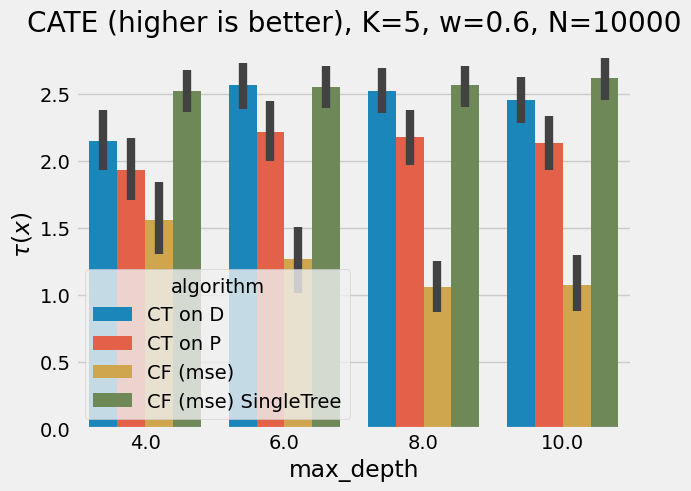

In [9]:
sns.barplot(x='max_depth', y='t', hue='algorithm', data=scores)
plt.title(f"CATE (higher is better), K={str(K)}, w={str(w)}, N={str(N)}")
plt.ylabel(r"$\tau(x)$")
plt.show()

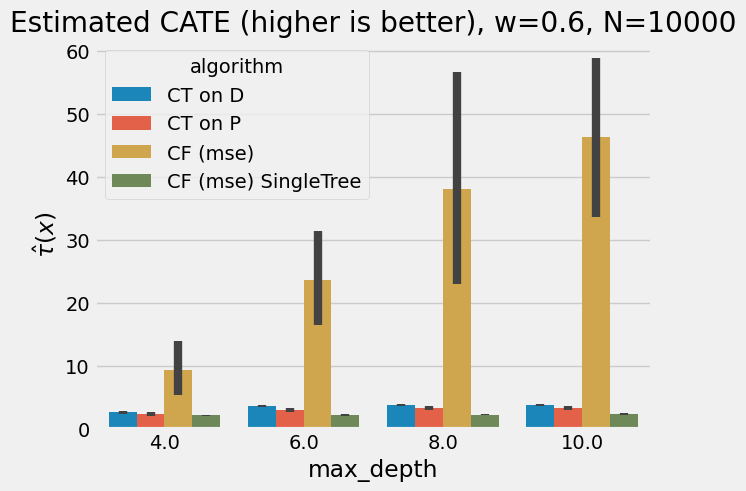

In [10]:
sns.barplot(x='max_depth', y='t_est',hue='algorithm', data=scores)
plt.title(fr"Estimated CATE (higher is better), w={str(w)}, N={str(N)}")
plt.ylabel(r"$\hat{{\tau}}(x)$")
plt.show()

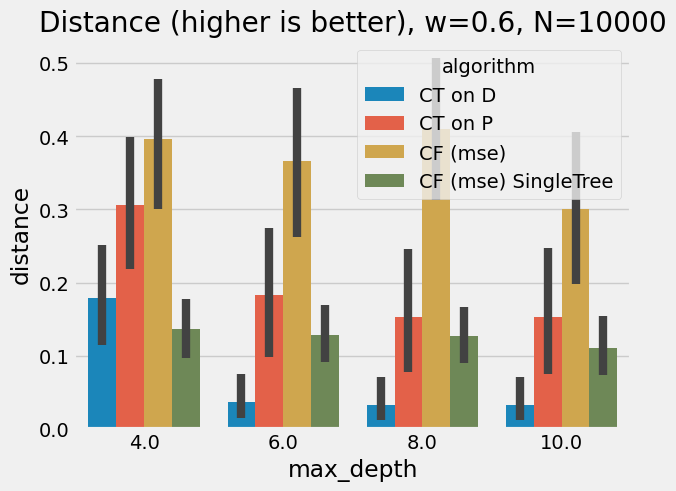

In [11]:
sns.barplot(x='max_depth', y='distance',hue='algorithm', data=scores)
plt.title(f"Distance (higher is better), w={str(w)}, N={str(N)}")
plt.show()

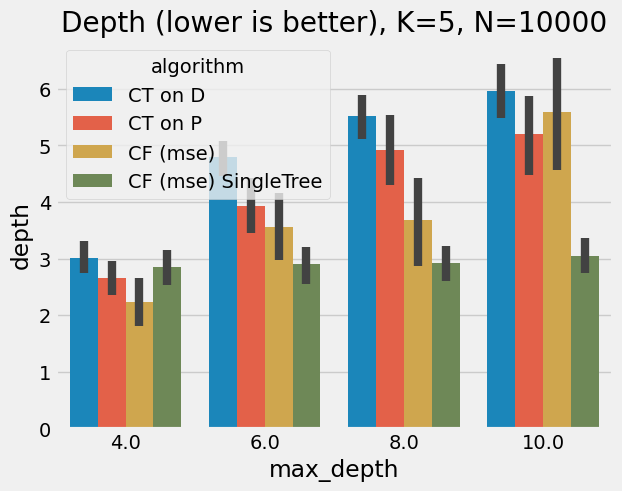

In [12]:
sns.barplot(x='max_depth', y='depth',hue='algorithm', data=scores)
plt.title(f"Depth (lower is better), K={str(K)}, N={str(N)}")
plt.show()

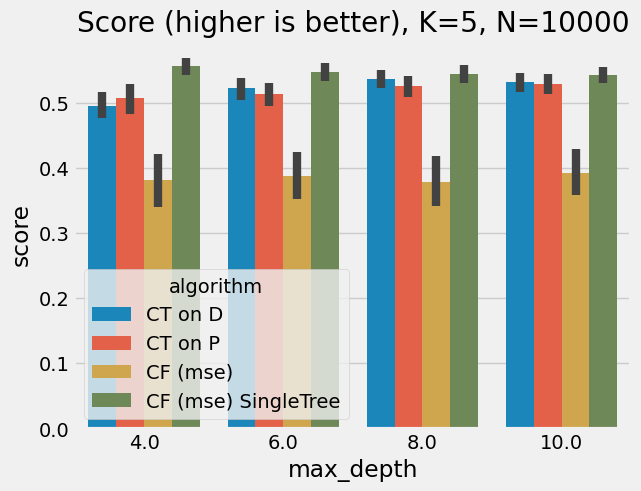

In [13]:
sns.barplot(x='max_depth', y='score',hue='algorithm', data=scores)
plt.title(f"Score (higher is better), K={str(K)}, N={str(N)}")
plt.show()

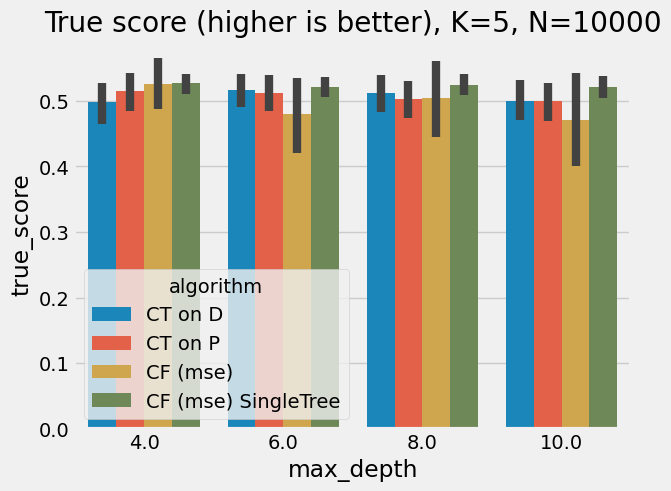

In [14]:
sns.barplot(x='max_depth', y='true_score',hue='algorithm', data=scores)
plt.title(f"True score (higher is better), K={str(K)}, N={str(N)}")
plt.show()